In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

print("All libraries loaded")

All libraries loaded


In [2]:
#Dataset Loading
df = pd.read_csv('/kaggle/input/datasets/yashdev01/spotify-tracks-dataset/spotify-tracks-dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (114000, 22)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [3]:
#Dataset Cleaning and Preprocessing
# All columns present in this dataset
ALL_COLS = [
    'track_id', 'artists', 'album_name', 'track_name', 'popularity',
    'duration_ms', 'explicit', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre'
]

df = df[ALL_COLS].dropna()

# Deduplicate by track identity
df = df.drop_duplicates(subset=['track_name', 'artists']).reset_index(drop=True)

# Fix types
df['explicit'] = df['explicit'].astype(bool)
df['mode']     = df['mode'].astype(int)       # 1 = major, 0 = minor
df['key']      = df['key'].astype(int)        # -1 = unknown

print(f"Clean shape: {df.shape}")
df.head(3)

Clean shape: (81343, 19)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,acoustic


In [4]:
#Feature Engineering
# ── Derived features ──────────────────────────────────────────

# 1. Duration in minutes (more interpretable than ms)
df['duration_min'] = df['duration_ms'] / 60_000

# 2. Mood score: blend of valence + energy (both 0-1)
#    High = happy & energetic, Low = sad & calm
df['mood_score'] = (df['valence'] + df['energy']) / 2

# 3. Acoustic-vs-electric index:
#    High acousticness + low energy = acoustic/mellow
#    Low acousticness + high energy = electric/loud
df['acoustic_electric'] = df['acousticness'] - df['energy']

# 4. Vocal presence score:
#    speechiness tells us spoken content, instrumentalness tells us absence of vocals
#    Combine: high speech + low instrumental = strong vocal presence
df['vocal_presence'] = df['speechiness'] - df['instrumentalness']

# 5. Live performance flag (soft):
#    liveness > 0.8 is Spotify's threshold for likely live recording
df['is_live'] = (df['liveness'] > 0.8).astype(int)

# 6. Key validity flag: -1 means Spotify couldn't detect the key
df['key_detected'] = (df['key'] >= 0).astype(int)

# 7. Tempo band (categorical → ordinal integer)
#    Slow < 90 BPM, Medium 90-130, Fast > 130
def tempo_band(t):
    if t < 90:   return 0   # slow
    elif t < 130: return 1  # medium
    else:         return 2  # fast

df['tempo_band'] = df['tempo'].apply(tempo_band)

# 8. Explicit as integer (already bool, cast to 0/1)
df['explicit_int'] = df['explicit'].astype(int)

print("Engineered features added:")
new_feats = ['duration_min','mood_score','acoustic_electric',
             'vocal_presence','is_live','key_detected','tempo_band','explicit_int']
print(df[new_feats].describe().round(3))

Engineered features added:
       duration_min  mood_score  acoustic_electric  vocal_presence    is_live  \
count     81343.000   81343.000          81343.000       81343.000  81343.000   
mean          3.857       0.549             -0.305          -0.096      0.034   
std           1.942       0.207              0.558           0.363      0.181   
min           0.143       0.000             -0.999          -1.000      0.000   
25%           2.898       0.414             -0.782          -0.083      0.000   
50%           3.587       0.568             -0.457           0.036      0.000   
75%           4.456       0.706              0.095           0.068      0.000   
max          87.288       0.986              0.996           0.965      1.000   

       key_detected  tempo_band  explicit_int  
count       81343.0   81343.000     81343.000  
mean            1.0       1.223         0.086  
std             0.0       0.687         0.280  
min             1.0       0.000         0.000  
25%

In [5]:
#Build Features
# ── Raw Spotify features ───────────────────────────────────────
SPOTIFY_FEATURES = [
    'danceability',       # 0-1
    'energy',             # 0-1
    'loudness',           # dB, typically -60 to 0
    'speechiness',        # 0-1
    'acousticness',       # 0-1
    'instrumentalness',   # 0-1
    'liveness',           # 0-1
    'valence',            # 0-1  (positivity/happiness)
    'tempo',              # BPM
    'duration_ms',        # ms
    'mode',               # 0 or 1
    'key',                # -1 to 11
    'popularity',         # 0-100
]

# ── Engineered features ────────────────────────────────────────
ENGINEERED_FEATURES = [
    'mood_score',          # (valence + energy) / 2
    'acoustic_electric',   # acousticness - energy
    'vocal_presence',      # speechiness - instrumentalness
    'tempo_band',          # 0/1/2 ordinal
    'explicit_int',        # 0/1
]

ALL_FEATURES = SPOTIFY_FEATURES + ENGINEERED_FEATURES

print(f"Total features used for recommendation: {len(ALL_FEATURES)}")
print(ALL_FEATURES)

# Scale everything to [0, 1]
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(df[ALL_FEATURES])
print(f"\nFeature matrix shape: {features_scaled.shape}")

Total features used for recommendation: 18
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'mode', 'key', 'popularity', 'mood_score', 'acoustic_electric', 'vocal_presence', 'tempo_band', 'explicit_int']

Feature matrix shape: (81343, 18)


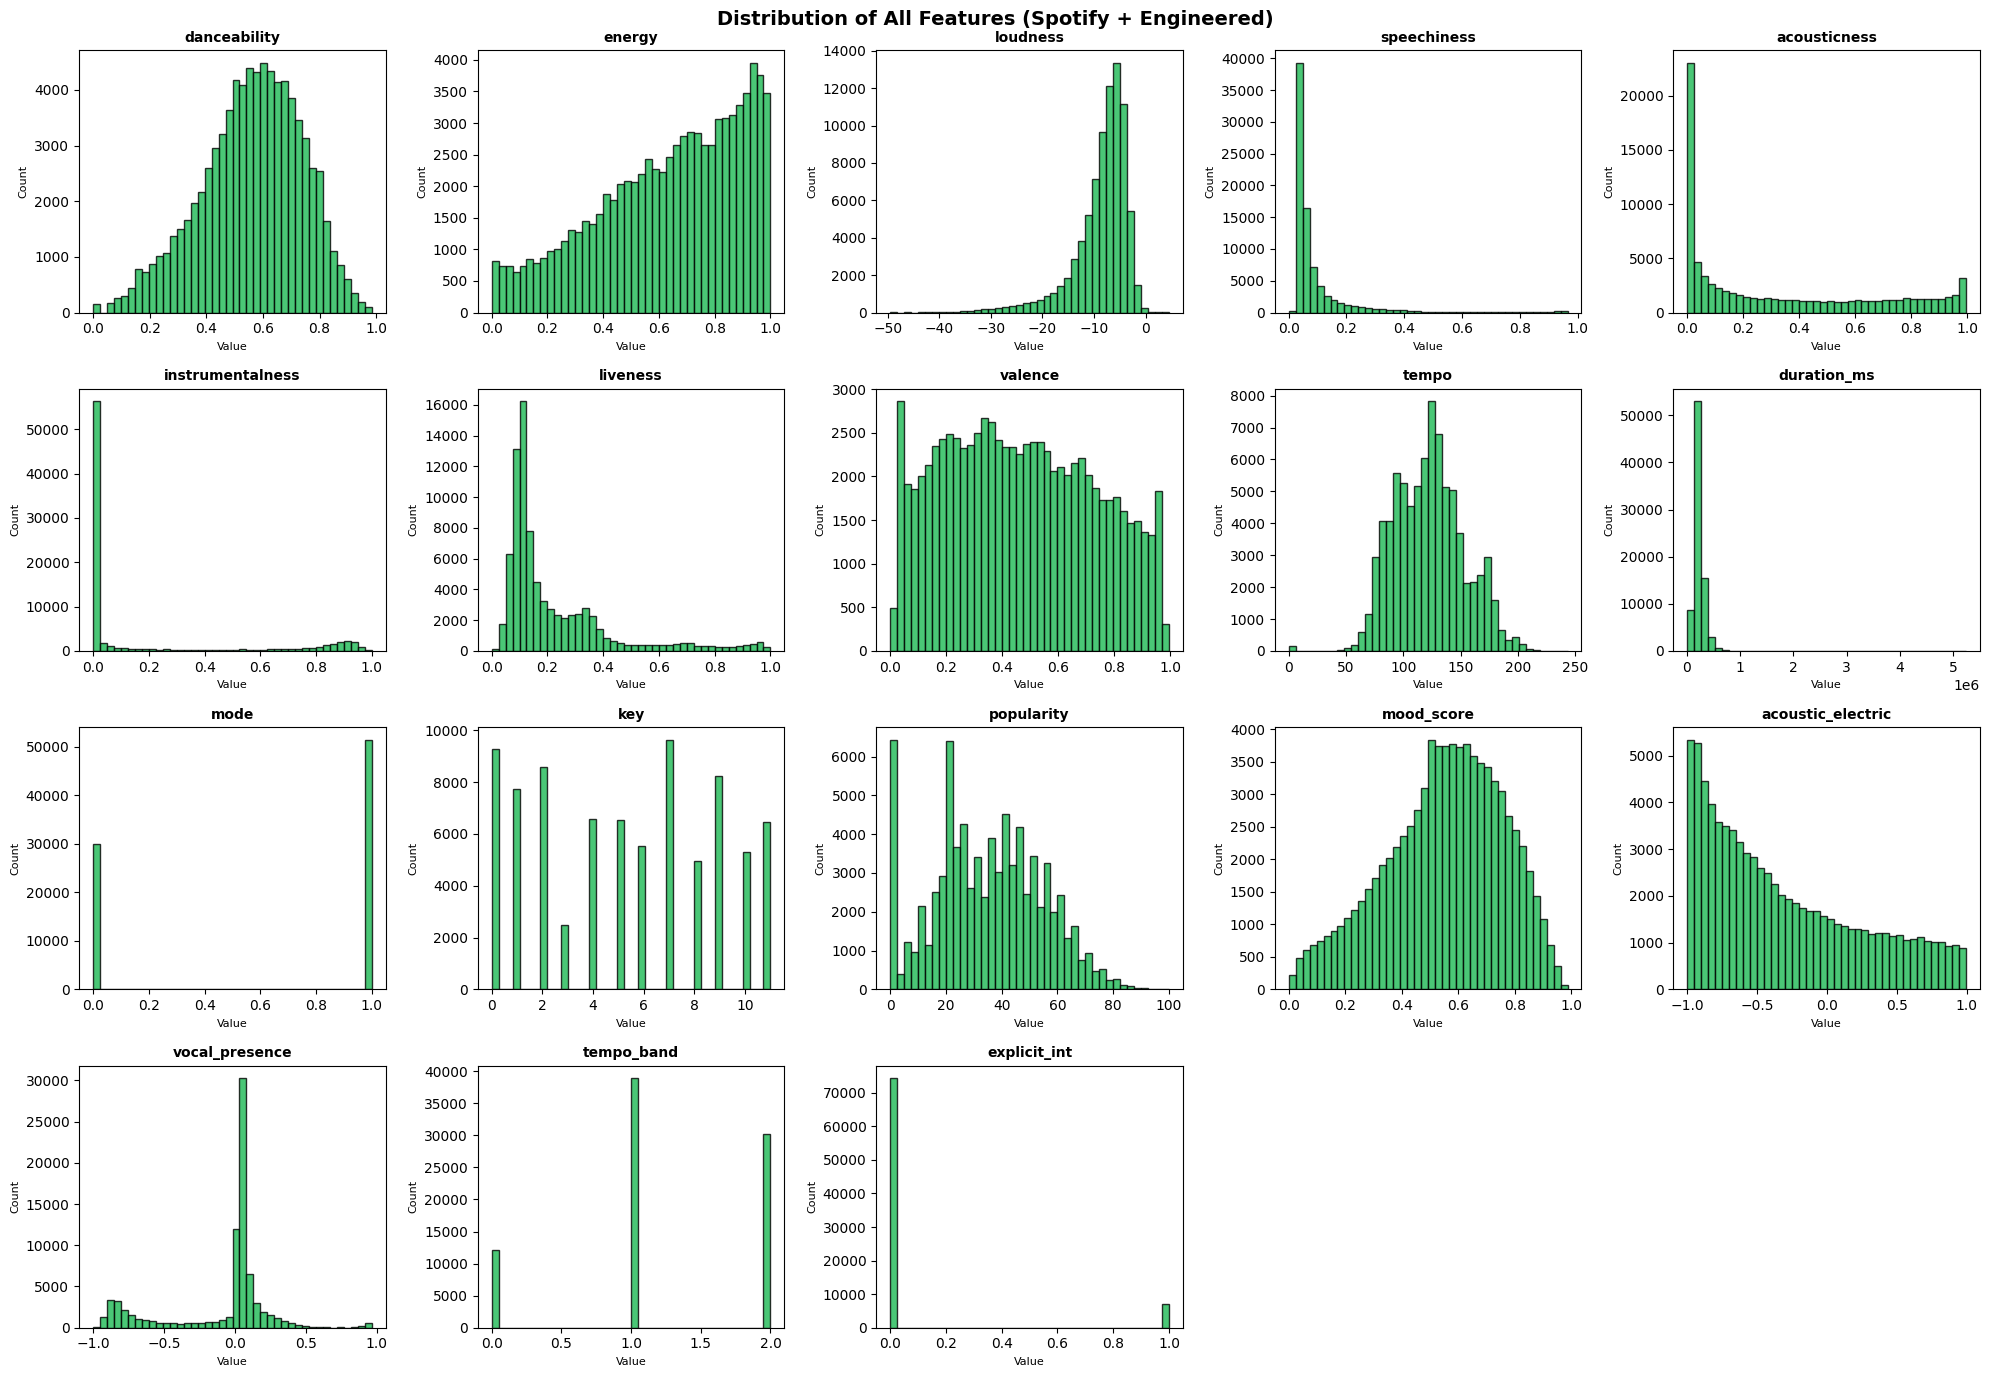

In [6]:
#EDA-Feature Distributions
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(ALL_FEATURES):
    axes[i].hist(df[feat], bins=40, color='#1DB954', edgecolor='black', alpha=0.8)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

# Hide unused subplot panels
for j in range(len(ALL_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features (Spotify + Engineered)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

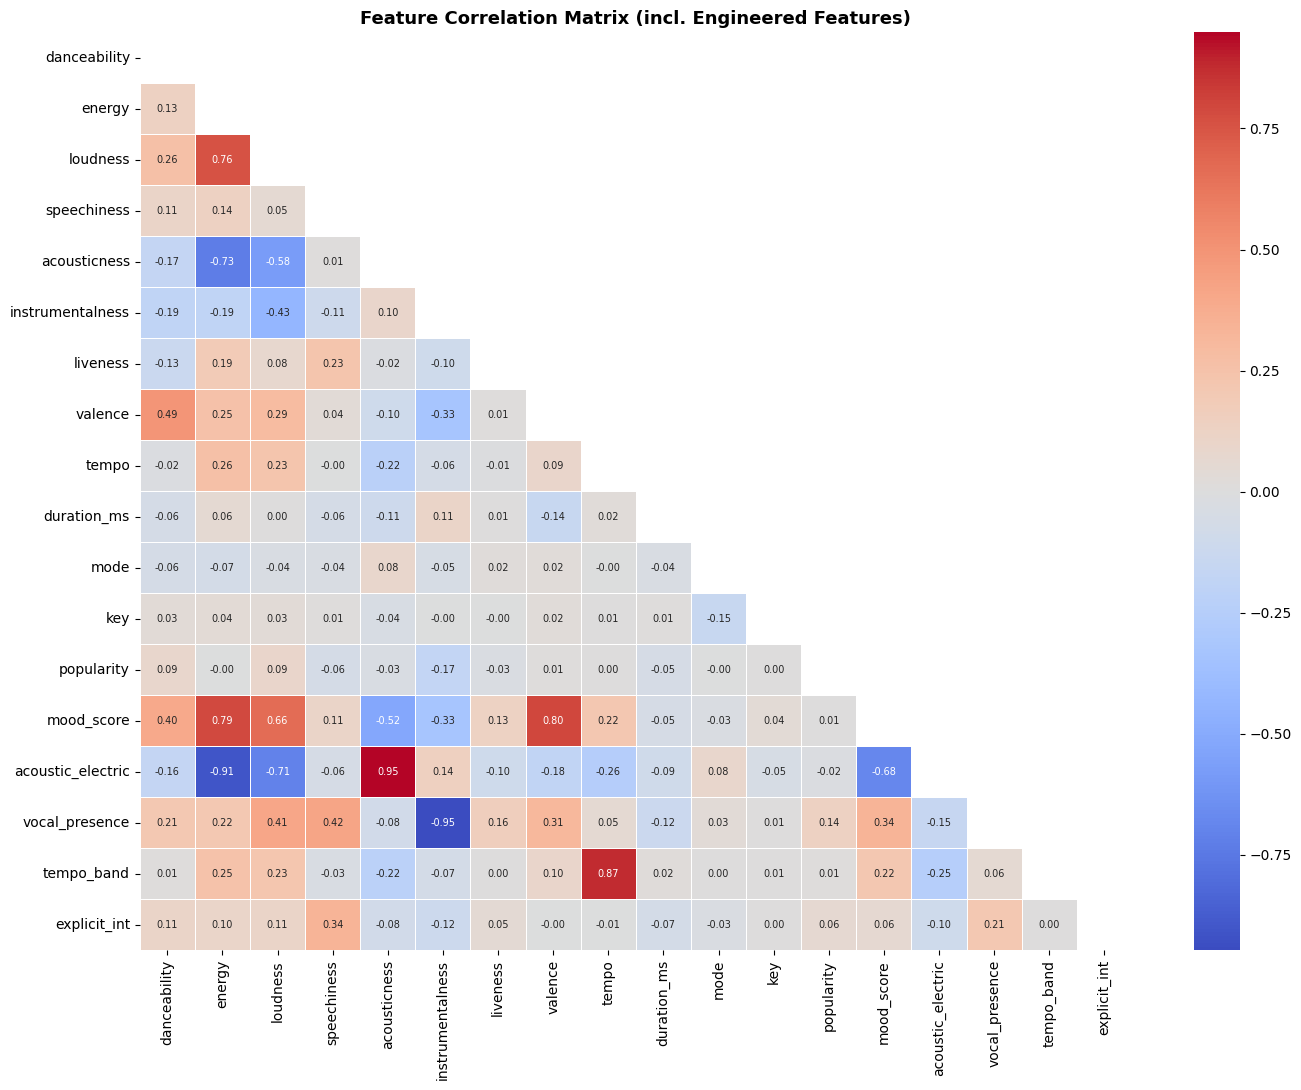

In [7]:
#EDA: Correlation Heatmap
plt.figure(figsize=(14, 11))
corr = df[ALL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix (incl. Engineered Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

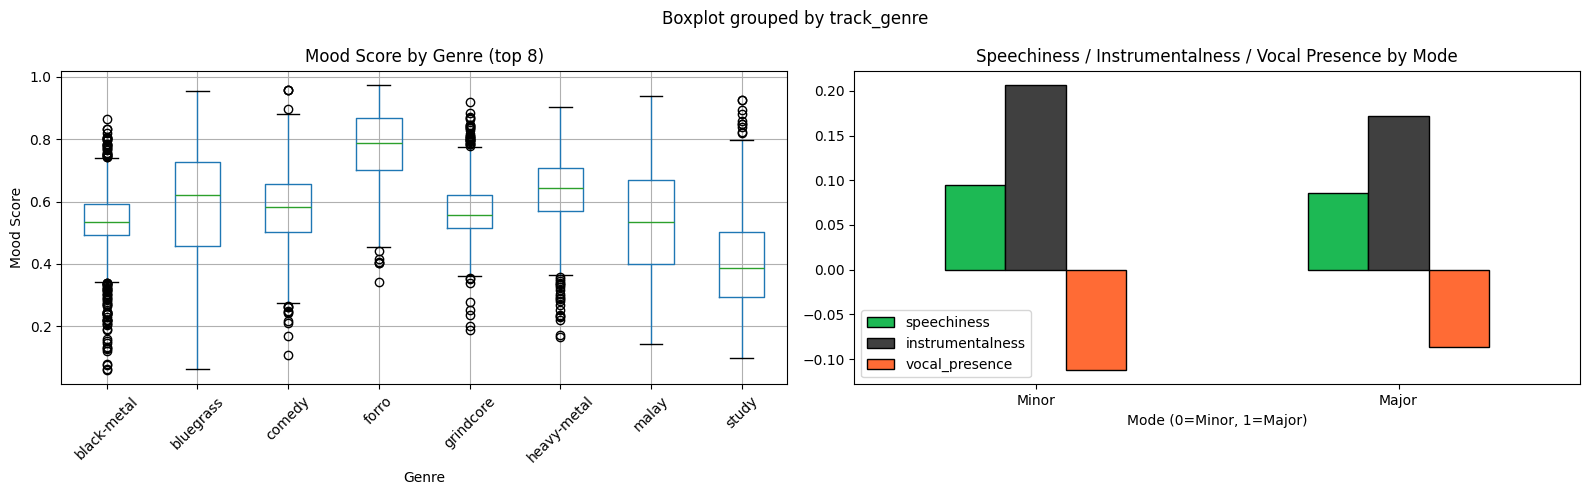

In [8]:
#EDA: Engineered Features vs Genre
# Show mood_score distribution across top-8 genres
top8 = df['track_genre'].value_counts().head(8).index.tolist()
df_top8 = df[df['track_genre'].isin(top8)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# mood_score by genre
df_top8.boxplot(column='mood_score', by='track_genre', ax=axes[0])
axes[0].set_title('Mood Score by Genre (top 8)')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Mood Score')
axes[0].tick_params(axis='x', rotation=45)

# vocal_presence by mode (major vs minor)
df.groupby('mode')[['speechiness','instrumentalness','vocal_presence']].mean().plot(
    kind='bar', ax=axes[1], color=['#1DB954','#404040','#FF6B35'], edgecolor='black'
)
axes[1].set_title('Speechiness / Instrumentalness / Vocal Presence by Mode')
axes[1].set_xlabel('Mode (0=Minor, 1=Major)')
axes[1].set_xticklabels(['Minor','Major'], rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
#KNN Model
N_NEIGHBORS = 21  # top-20 + query itself

knn_model = NearestNeighbors(
    n_neighbors=N_NEIGHBORS,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)
knn_model.fit(features_scaled)

print(f"KNN trained on {features_scaled.shape[0]:,} songs with {features_scaled.shape[1]} features ")

KNN trained on 81,343 songs with 18 features 


In [10]:
#Recommendation
def find_song_index(track_name, artist_name=None):
    name_mask = df['track_name'].str.lower() == track_name.lower()
    if artist_name:
        artist_mask = df['artists'].str.lower().str.contains(artist_name.lower())
        matches = df[name_mask & artist_mask]
    else:
        matches = df[name_mask]
    return -1 if matches.empty else matches.index[0]


def recommend_songs(track_name, artist_name=None, n_recommendations=10,
                    same_genre_only=True,
                    language_boost=5.0):
    """
    Recommend songs similar to a given track using all audio + engineered features.

    Parameters
    ----------
    track_name            : Name of the seed song
    artist_name           : Optional – disambiguate songs with the same name
    n_recommendations     : How many songs to return (default 10)
    same_genre_only       : If True, restrict to the same genre label
    prefer_same_language  : If True, same-language songs are strongly preferred
    language_boost        : Points added to similarity for language match (default 5.0)
    """
    idx = find_song_index(track_name, artist_name)
    if idx == -1:
        print(f" '{track_name}' not found. Check spelling or add artist name.")
        return pd.DataFrame()

    q = df.iloc[idx]
   

    print(f"\n Query  : '{q['track_name']}' by {q['artists']}")
    print(f"   Album  : {q['album_name']}")
    print(f"   Genre  : {q['track_genre']}  |  Popularity: {q['popularity']}")
    print(f"   Mode   : {'Major' if q['mode'] == 1 else 'Minor'}  |  Key: {q['key'] if q['key'] >= 0 else 'Unknown'}")
    print(f"   Mood   : {q['mood_score']:.2f}  |  Vocal presence: {q['vocal_presence']:.2f}")
    print(f"   Explicit: {'Yes' if q['explicit'] else 'No'}  |  Duration: {q['duration_min']:.1f} min")
    print("-" * 60)

    # ── Step 1: Fetch a LARGE candidate pool from KNN ─────────
    # We ask for more neighbors so after language filtering we still
    # have enough candidates to fill n_recommendations
    pool_size = min(len(df), max(200, n_recommendations * 20))
    query_vec = features_scaled[idx].reshape(1, -1)
    distances, indices = knn_model.kneighbors(query_vec, n_neighbors=pool_size)
    similarity_scores  = (1 - distances[0]) * 100

    recs = df.iloc[indices[0]].copy()
    recs['Similarity (%)'] = similarity_scores.round(2)
    recs = recs[recs.index != idx]  # drop seed itself

    # ── Step 2: Genre filter (optional) ───────────────────────
    if same_genre_only:
        recs = recs[recs['track_genre'] == q['track_genre']]


    # ──────────────────────────────────────────────────────────

    display_cols = ['track_name', 'artists', 'album_name', 'track_genre',
                    'popularity', 'mood_score', 'Similarity (%)']
    rename_map   = {
        'track_name':  'Track',
        'artists':     'Artist',
        'album_name':  'Album',
        'track_genre': 'Genre',
        'popularity':  'Popularity',
        'mood_score':  'Mood',
    }

    if 'language' in recs.columns:
        display_cols.insert(4, 'language')
        rename_map['language'] = 'Language'

    recs = (
        recs
        .head(n_recommendations)
        [display_cols]
        .rename(columns=rename_map)
        .reset_index(drop=True)
    )
    recs.index += 1
    recs['Mood'] = recs['Mood'].round(2)
    return recs


def recommend_from_profile(feature_dict, n_recommendations=10):
    """
    Recommend songs that match a custom mood/audio profile.

    Supply any combination of raw Spotify values or engineered values.
    Missing features default to the dataset mean.
    """
    base = df[ALL_FEATURES].mean().to_dict()
    base.update(feature_dict)

    custom_vec    = np.array([[base[f] for f in ALL_FEATURES]])
    custom_scaled = scaler.transform(custom_vec)

    distances, indices = knn_model.kneighbors(custom_scaled, n_neighbors=n_recommendations)
    similarity_scores  = (1 - distances[0]) * 100

    recs = df.iloc[indices[0]].copy()
    recs['Similarity (%)'] = similarity_scores.round(2)
    recs = (
        recs
        [['track_name', 'artists', 'track_genre', 'popularity', 'mood_score', 'Similarity (%)']]
        .rename(columns={
            'track_name':  'Track',
            'artists':     'Artist',
            'track_genre': 'Genre',
            'popularity':  'Popularity',
            'mood_score':  'Mood',
        })
        .reset_index(drop=True)
    )
    recs.index += 1
    recs['Mood'] = recs['Mood'].round(2)
    return recs


print("Functions ready")

Functions ready


In [11]:
#Demo Cell
import time
import random

def autonomous_demo(
    n_rounds: int = 5,
    n_recommendations: int = 10,
    pause_between: float = 1.5,   # seconds between rounds
    mode: str = 'random'          # 'random', 'chain', or 'genre_hop'
):
    """
    Runs recommend_songs autonomously without any user input.

    Modes:
      'random'     — picks a fresh random seed each round (independent)
      'chain'      — each round's seed = top recommendation from previous round
      'genre_hop'  — picks a random seed from a different genre each round
    """

    print("=" * 65)
    print(f"AUTONOMOUS RECOMMENDATION DEMO")
    print(f"Mode: {mode.upper()} | Rounds: {n_rounds} | Recs per round: {n_recommendations}")
    print("=" * 65)

    current_idx = None

    for round_num in range(1, n_rounds + 1):

        # ── Pick seed based on mode ──────────────────────────────
        if mode == 'random' or current_idx is None:
            current_idx = random.randint(0, len(df) - 1)

        elif mode == 'chain':
            # seed is already updated at end of loop
            pass

        elif mode == 'genre_hop':
            if round_num == 1:
                current_idx = random.randint(0, len(df) - 1)
            else:
                # Pick a random song from a DIFFERENT genre than last round
                last_genre = df.iloc[current_idx]['track_genre']
                other_genres = df[df['track_genre'] != last_genre]
                current_idx = other_genres.sample(1).index[0]

        seed_song = df.iloc[current_idx]

        print(f"\n{'─'*65}")
        print(f"  Round {round_num}/{n_rounds}")
        print(f"  Seed  : {seed_song['track_name']} — {seed_song['artists']}")
        print(f"  Genre : {seed_song['track_genre']} | Mood: {seed_song['mood_score']:.2f} | Pop: {seed_song['popularity']}")
        print(f"{'─'*65}")

        # ── Run recommendation ───────────────────────────────────
        recs = recommend_songs(
            track_name       = seed_song['track_name'],
            artist_name      = seed_song['artists'].split(';')[0].strip(),
            n_recommendations= n_recommendations
        )

        if not recs.empty:
            print(recs.to_string())

            # In 'chain' mode, next seed = top recommendation
            if mode == 'chain':
                top_rec_name   = recs.iloc[0]['Track']
                top_rec_artist = recs.iloc[0]['Artist']
                match = df[
                    (df['track_name'] == top_rec_name) &
                    (df['artists'].str.contains(top_rec_artist.split(';')[0].strip()))
                ]
                if not match.empty:
                    current_idx = match.index[0]
                else:
                    current_idx = random.randint(0, len(df) - 1)
        else:
            print("  No recommendations found, skipping round.")
            current_idx = random.randint(0, len(df) - 1)

        if round_num < n_rounds:
            time.sleep(pause_between)

    print(f"\n{'='*65}")
    print("Demo complete.")
    print(f"{'='*65}")

In [12]:
# Each round picks a completely random seed
autonomous_demo(n_rounds=5, n_recommendations=5, mode='random')

AUTONOMOUS RECOMMENDATION DEMO
Mode: RANDOM | Rounds: 5 | Recs per round: 5

─────────────────────────────────────────────────────────────────
  Round 1/5
  Seed  : 指望遠鏡 — Nogizaka46
  Genre : j-idol | Mood: 0.81 | Pop: 18
─────────────────────────────────────────────────────────────────

 Query  : '指望遠鏡' by Nogizaka46
   Album  : 制服のマネキン TypeA
   Genre  : j-idol  |  Popularity: 18
   Mode   : Major  |  Key: 0
   Mood   : 0.81  |  Vocal presence: 0.05
   Explicit: No  |  Duration: 3.4 min
------------------------------------------------------------
                      Track         Artist                       Album   Genre  Popularity  Mood  Similarity (%)
1    アーモンドクロワッサン計画/Team BII          NMB48      てっぺんとったんで! (通常盤Type-B)  j-idol          19  0.82           99.64
2  誰もいない森の奥で一本の木が倒れたら音はするか?            ≠ME  まほろばアスタリスク Special Edition  j-idol          31  0.77           99.62
3                   花は誰のもの?          STU48     花は誰のもの? Special Edition  j-idol          24  0.72          

In [13]:
# Each round's seed = the top pick from the previous round
# Creates a chain: Song A → best match B → best match of B → ...
autonomous_demo(n_rounds=5, n_recommendations=10, mode='chain')

AUTONOMOUS RECOMMENDATION DEMO
Mode: CHAIN | Rounds: 5 | Recs per round: 10

─────────────────────────────────────────────────────────────────
  Round 1/5
  Seed  : Halloween Dance — Christopher Zondaflex Tyler
  Genre : kids | Mood: 0.42 | Pop: 14
─────────────────────────────────────────────────────────────────

 Query  : 'Halloween Dance' by Christopher Zondaflex Tyler
   Album  : Halloween Dance
   Genre  : kids  |  Popularity: 14
   Mode   : Major  |  Key: 1
   Mood   : 0.42  |  Vocal presence: 0.18
   Explicit: No  |  Duration: 1.9 min
------------------------------------------------------------
                                  Track                       Artist                                                         Album Genre  Popularity  Mood  Similarity (%)
1                         Drive the Car  Christopher Zondaflex Tyler                                    Mr Chris' Hip Hop for Tots  kids          14  0.44           99.55
2                   Backpack, Backpack!          

In [14]:
# Each round jumps to a different genre — good for discovery
autonomous_demo(n_rounds=5, n_recommendations=10, mode='genre_hop')

AUTONOMOUS RECOMMENDATION DEMO
Mode: GENRE_HOP | Rounds: 5 | Recs per round: 10

─────────────────────────────────────────────────────────────────
  Round 1/5
  Seed  : Maahi Ve — Shankar-Ehsaan-Loy;Sadhana Sargam;Sujata Bhattacharya;Udit Narayan;Sonu Nigam
  Genre : pop-film | Mood: 0.70 | Pop: 63
─────────────────────────────────────────────────────────────────

 Query  : 'Maahi Ve' by Shankar-Ehsaan-Loy;Sadhana Sargam;Sujata Bhattacharya;Udit Narayan;Sonu Nigam
   Album  : Kal Ho Naa Ho (Original Motion Picture Soundtrack)
   Genre  : pop-film  |  Popularity: 63
   Mode   : Minor  |  Key: 7
   Mood   : 0.70  |  Vocal presence: 0.08
   Explicit: No  |  Duration: 6.1 min
------------------------------------------------------------
                              Track                                                         Artist                                       Album     Genre  Popularity  Mood  Similarity (%)
1  O Saki Saki (From "Batla House")  Neha Kakkar;Tulsi Kumar;B Praak;Ta

In [15]:
# High energy dance / party
print(" Party / Dance profile")
recommend_from_profile({
    'danceability': 0.88, 'energy': 0.92, 'valence': 0.80,
    'loudness': -4.0, 'tempo': 128.0, 'acousticness': 0.03,
    'speechiness': 0.07, 'instrumentalness': 0.01,
    'mode': 1,               # major key (happy)
    'explicit_int': 0,
    'mood_score': 0.86,      # engineered: happy + energetic
    'tempo_band': 2,         # fast
})

 Party / Dance profile


,Track,Artist,Genre,Popularity,Mood,Similarity (%)
1,Já Sabe,Simone & Simaria,sertanejo,44,0.82,99.23
2,Hey,Cosmos People,mandopop,23,0.76,99.22
3,Anytime Woman - Remastered 2022,Eikichi Yazawa,j-rock,33,0.78,99.22
4,四月の風,SILENT SIREN,j-idol,19,0.80,99.21
5,Mayday,NRG,techno,27,0.78,99.13
6,雨のリゾート,Seiko Matsuda,j-idol,27,0.79,99.10
7,旅立ちはフリージア,Seiko Matsuda,j-idol,30,0.79,99.10
8,Khaf Malakanda,K. G. Markose,malay,27,0.72,99.09
9,Necesito Tu Amor,Fidel Nadal,alt-rock,45,0.80,99.08
10,Senior Service,Elvis Costello & The Attractions,power-pop,28,0.82,99.04


In [16]:
# Chill / instrumental / study
print("Chill / Study profile")
recommend_from_profile({
    'danceability': 0.38, 'energy': 0.18, 'valence': 0.28,
    'loudness': -18.0, 'tempo': 72.0, 'acousticness': 0.85,
    'speechiness': 0.03, 'instrumentalness': 0.80,
    'mode': 0,               # minor key (melancholic)
    'mood_score': 0.23,
    'acoustic_electric': 0.67,  # very acoustic
    'vocal_presence': -0.77,    # mostly instrumental
    'tempo_band': 0,            # slow
})

Chill / Study profile


,Track,Artist,Genre,Popularity,Mood,Similarity (%)
1,All The World (I Tell Myself),Correatown,acoustic,38,0.28,99.20
2,Politik,Sweet Little Band,children,33,0.20,99.02
3,First Love - Lofi Edit,Smyang Piano;tamagopalette,piano,38,0.23,98.99
4,Avid,Jake Eaw,piano,46,0.27,98.83
5,Bhavani's Limitless Love for Dad - Instrumental,Arrol Corelli,indian,42,0.16,98.81
6,"Symphony No. 25 in G Minor, K. 183: I. Allegro...",Wolfgang Amadeus Mozart;Academy of St. Martin ...,classical,61,0.30,98.77
7,Lament,George Winston,new-age,28,0.19,98.75
8,Cortes de Aragón,Roberto Diana;Muniesa,acoustic,47,0.16,98.61
9,180 Gram,Dusty Decks,study,37,0.26,98.53
10,Versace Strings,Smerz,club,22,0.14,98.52


In [17]:
# Sad / emotional
print("Sad / Emotional profile")
recommend_from_profile({
    'valence': 0.10, 'energy': 0.25, 'acousticness': 0.75,
    'danceability': 0.30, 'loudness': -14.0,
    'mode': 0,               # minor key
    'mood_score': 0.175,
    'tempo_band': 0,
})

Sad / Emotional profile


,Track,Artist,Genre,Popularity,Mood,Similarity (%)
1,Kabhii Tumhhe - Lofi Flip,VIBIE;Darshan Raval;Javed-Mohsin,indian,54,0.29,95.52
2,Baby Teeth,Flower Face,ambient,53,0.27,95.24
3,Seninim Son Kez,Teoman;İrem Candar,turkish,47,0.32,95.21
4,Graceland Drive,Justnormal,study,33,0.27,95.19
5,Historia De Un Amor,Il Volo,opera,30,0.32,95.12
6,El Reloj,Il Volo,opera,34,0.31,94.97
7,Dhadak Title Track,Ajay Gogavale;Shreya Ghoshal,pop-film,58,0.27,94.90
8,Atlantis (Sped Up),fenekot,chill,32,0.34,94.88
9,Kadın,Birsen Tezer,j-rock,41,0.36,94.76
10,你不是第一個離開的人,G.E.M.,mandopop,59,0.23,94.75


Genre Hit Rate @ top-10 (500 samples): 13.52%


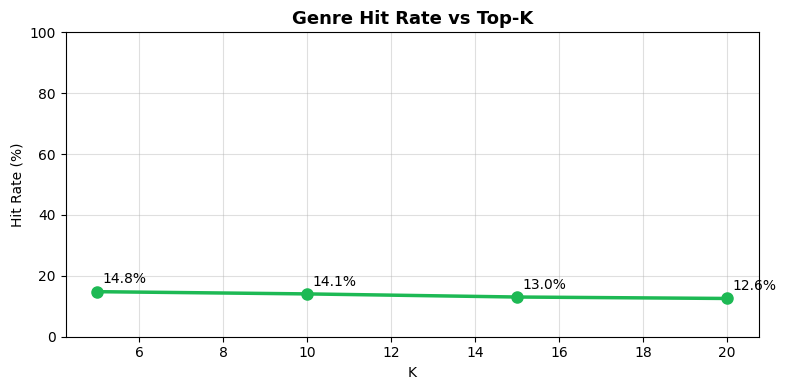

In [18]:
#Evaluation
def genre_hit_rate(n_samples=500, top_k=10):
    np.random.seed(42)
    indices = np.random.choice(len(df), size=n_samples, replace=False)
    rates   = []
    for idx in indices:
        query_genre = df.iloc[idx]['track_genre']
        q_vec       = features_scaled[idx].reshape(1, -1)
        dists, idxs = knn_model.kneighbors(q_vec, n_neighbors=top_k + 1)
        neighbors   = [i for i in idxs[0] if i != idx][:top_k]
        genres      = df.iloc[neighbors]['track_genre'].values
        rates.append(np.sum(genres == query_genre) / top_k)
    return np.mean(rates) * 100

score = genre_hit_rate(500, 10)
print(f"Genre Hit Rate @ top-10 (500 samples): {score:.2f}%")

# Across K values
k_values = [5, 10, 15, 20]
scores   = [genre_hit_rate(300, k) for k in k_values]

plt.figure(figsize=(8, 4))
plt.plot(k_values, scores, marker='o', color='#1DB954', linewidth=2.5, markersize=8)
for k, s in zip(k_values, scores):
    plt.annotate(f'{s:.1f}%', (k, s), textcoords='offset points', xytext=(4, 6), fontsize=10)
plt.title('Genre Hit Rate vs Top-K', fontsize=13, fontweight='bold')
plt.xlabel('K'); plt.ylabel('Hit Rate (%)')
plt.ylim(0, 100); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

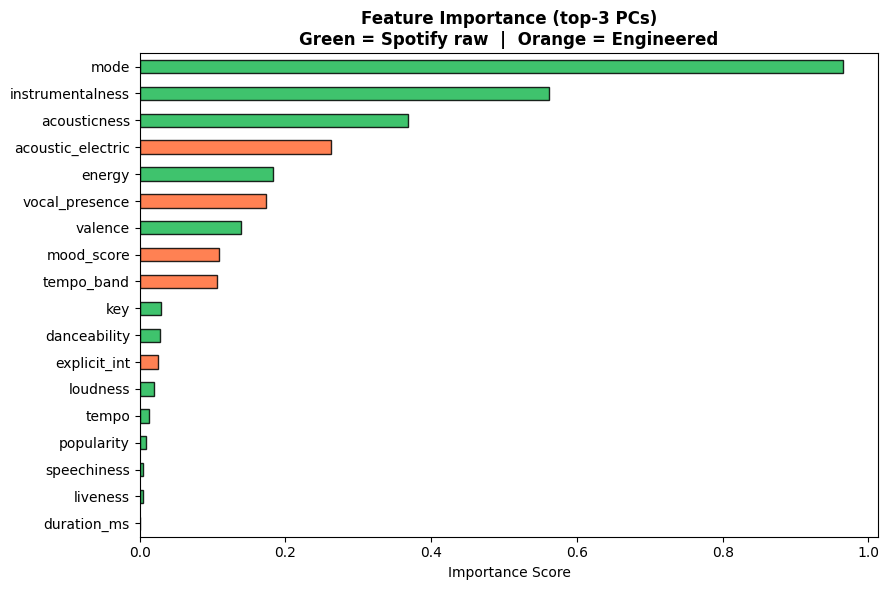


Top 5 most important features:
mode                 0.9651
instrumentalness     0.5615
acousticness         0.3679
acoustic_electric    0.2631
energy               0.1836
dtype: float64


In [19]:
#Feature Importance
pca = PCA(n_components=len(ALL_FEATURES), random_state=42)
pca.fit(features_scaled)

# Sum of squared loadings across top-3 PCs = contribution to explained variance
loadings   = pd.DataFrame(pca.components_.T, index=ALL_FEATURES,
                           columns=[f'PC{i+1}' for i in range(len(ALL_FEATURES))])
importance = (loadings[['PC1','PC2','PC3']] ** 2).sum(axis=1).sort_values(ascending=True)

colors = ['#FF6B35' if f in ENGINEERED_FEATURES else '#1DB954' for f in importance.index]

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color=colors, edgecolor='black', alpha=0.85)
plt.title('Feature Importance (top-3 PCs)\nGreen = Spotify raw  |  Orange = Engineered',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance.sort_values(ascending=False).head(5).round(4))

In [20]:
#Save Model
import joblib

joblib.dump(knn_model,      'knn_recommender.pkl')
joblib.dump(scaler,         'minmax_scaler.pkl')
df.to_csv('clean_dataset.csv', index=False)
np.save('features_scaled.npy', features_scaled)

print("Saved: knn_recommender.pkl | minmax_scaler.pkl | clean_dataset.csv | features_scaled.npy")

Saved: knn_recommender.pkl | minmax_scaler.pkl | clean_dataset.csv | features_scaled.npy


In [21]:
#Autoqueue
from collections import deque

class MusicAutoQueue:
    """
    Automated next-song engine.

    How it works:
    - Maintains a queue of upcoming songs
    - When a song finishes, picks the best unused neighbor of the CURRENT song
    - Adds slight randomness so the queue never feels mechanical
    - Tracks play history to avoid repeating songs
    - Uses a 'drift' mechanism: every N songs, re-anchors to a fresh
      neighbor of the original seed so the queue doesn't stray too far
    """

    def __init__(
        self,
        seed_track_name: str,
        artist_name: str = None,
        queue_size: int = 5,       # songs to pre-load ahead
        randomness: float = 0.15,  # 0 = pure similarity, 1 = pure random
        rediscover_every: int = 8, # re-anchor to seed every N songs
        avoid_genre_lock: bool = True  # mix in cross-genre picks occasionally
    ):
        self.queue_size       = queue_size
        self.randomness       = randomness
        self.rediscover_every = rediscover_every
        self.avoid_genre_lock = avoid_genre_lock

        self.history        = []    # track_ids already played
        self.play_count     = 0
        self.current_idx    = None
        self.seed_idx       = None
        self.current_song   = None

        # Start from seed
        seed_idx = find_song_index(seed_track_name, artist_name)
        if seed_idx == -1:
            raise ValueError(f"Song '{seed_track_name}' not found.")

        self.seed_idx     = seed_idx
        self.current_idx  = seed_idx
        self.current_song = df.iloc[seed_idx]
        self.history.append(df.iloc[seed_idx]['track_id'])

        # Pre-fill the queue
        self.queue = deque()
        self._fill_queue()

        print(f"Queue initialized. Now playing:\n")
        self._print_song(df.iloc[seed_idx], tag="NOW PLAYING", number=0)

    # ── Internal helpers ───────────────────────────────────────

    def _get_neighbors(self, idx, n=50):
        """Fetch top-N KNN neighbors for a given song index."""
        vec = features_scaled[idx].reshape(1, -1)
        dists, idxs = knn_model.kneighbors(vec, n_neighbors=min(n + 1, len(df)))
        sims = (1 - dists[0]) * 100
        results = []
        for i, sim in zip(idxs[0], sims):
            if i != idx:
                results.append((i, sim))
        return results  # [(song_idx, similarity_score), ...]

    def _pick_next(self, from_idx):
        """
        Pick the next song from neighbors of `from_idx`.
        Applies randomness and avoids already-played songs.
        """
        neighbors = self._get_neighbors(from_idx, n=60)

        # Filter out history
        candidates = [(i, s) for i, s in neighbors
                      if df.iloc[i]['track_id'] not in self.history]

        if not candidates:
            # History too long — soft-reset (keep last 10 only)
            recent = set([df.iloc[i]['track_id'] for i in
                         [self.history[-j] for j in range(1, min(10, len(self.history)+1))]])
            candidates = [(i, s) for i, s in neighbors
                          if df.iloc[i]['track_id'] not in recent]
            if not candidates:
                candidates = neighbors[:20]  # full fallback

        # Randomness: sample from top-K with score-weighted probability
        top_k = max(3, int(len(candidates) * (1 - self.randomness) * 0.4 + 3))
        pool  = candidates[:top_k]

        scores = np.array([s for _, s in pool])
        # Add noise proportional to randomness setting
        noise  = np.random.uniform(0, self.randomness * 20, size=len(scores))
        scores = scores + noise

        chosen_idx = pool[np.argmax(scores)][0]

        # Occasionally inject a cross-genre pick for variety
        if self.avoid_genre_lock and self.play_count % 5 == 4:
            curr_genre = df.iloc[from_idx]['track_genre']
            cross = [(i, s) for i, s in candidates
                     if df.iloc[i]['track_genre'] != curr_genre]
            if cross:
                chosen_idx = cross[0][0]

        return chosen_idx

    def _fill_queue(self):
        """Fill the pre-load queue up to queue_size."""
        anchor = self.current_idx

        # Every N songs, re-anchor to seed for thematic coherence
        if self.play_count > 0 and self.play_count % self.rediscover_every == 0:
            anchor = self.seed_idx

        while len(self.queue) < self.queue_size:
            next_idx = self._pick_next(anchor)
            if next_idx not in [q[0] for q in self.queue]:
                next_song = df.iloc[next_idx]
                sim = (1 - knn_model.kneighbors(
                    features_scaled[self.current_idx].reshape(1,-1),
                    n_neighbors=1)[0][0][0]) * 100
                # Get actual similarity to current song
                vec  = features_scaled[self.current_idx].reshape(1,-1)
                dists, idxs = knn_model.kneighbors(vec, n_neighbors=60)
                sim_map = {j: (1-d)*100 for j, d in zip(idxs[0], dists[0])}
                sim_score = sim_map.get(next_idx, 0.0)
                self.queue.append((next_idx, sim_score))
                anchor = next_idx  # chain for smooth flow

    def _print_song(self, song, tag="PLAYING", number=None, sim=None):
        num_str = f"#{number} " if number is not None else ""
        sim_str = f" | Match: {sim:.1f}%" if sim is not None else ""
        mode    = 'Major' if song['mode'] == 1 else 'Minor'
        print(f"  [{tag}] {num_str}{song['track_name']}")
        print(f"          Artist : {song['artists']}")
        print(f"          Album  : {song['album_name']}")
        print(f"          Genre  : {song['track_genre']}{sim_str}")
        print(f"          Mood   : {song['mood_score']:.2f}  |  Mode: {mode}  |  Popularity: {song['popularity']}")
        print()

    # ── Public API ─────────────────────────────────────────────

    def next_song(self):
        """
        Advance the queue. Call this when the current song ends.
        Returns the next song as a pandas Series.
        """
        if not self.queue:
            self._fill_queue()

        next_idx, sim_score = self.queue.popleft()
        self.play_count    += 1
        self.current_idx    = next_idx
        self.current_song   = df.iloc[next_idx]
        self.history.append(df.iloc[next_idx]['track_id'])

        # Re-fill the look-ahead queue
        self._fill_queue()

        self._print_song(self.current_song,
                         tag="NOW PLAYING",
                         number=self.play_count,
                         sim=sim_score)
        return self.current_song

    def skip(self):
        """Skip current and jump to the next queued song."""
        print(f"  [SKIPPED] {self.current_song['track_name']}\n")
        return self.next_song()

    def peek_queue(self):
        """Preview upcoming songs without advancing."""
        print(f"  Upcoming ({len(self.queue)} songs pre-loaded):")
        print(f"  {'#':<4} {'Song':<35} {'Artist':<25} {'Genre':<20} {'Match':>6}")
        print(f"  {'-'*95}")
        for i, (idx, sim) in enumerate(self.queue, 1):
            s = df.iloc[idx]
            name   = s['track_name'][:33]
            artist = s['artists'][:23]
            genre  = s['track_genre'][:18]
            print(f"  {i:<4} {name:<35} {artist:<25} {genre:<20} {sim:>5.1f}%")
        print()

    def show_history(self):
        """Show all songs played so far."""
        print(f"  Play history ({len(self.history)} songs):")
        print(f"  {'#':<4} {'Song':<35} {'Artist':<25} {'Genre':<20}")
        print(f"  {'-'*88}")
        for i, tid in enumerate(self.history):
            s = df[df['track_id'] == tid].iloc[0]
            name   = s['track_name'][:33]
            artist = s['artists'][:23]
            genre  = s['track_genre'][:18]
            print(f"  {i:<4} {name:<35} {artist:<25} {genre:<20}")
        print()

    def rewind(self):
        """Go back to the previous song."""
        if len(self.history) < 2:
            print("  Nothing to rewind to.")
            return self.current_song
        # Put current back in front of queue
        self.queue.appendleft((self.current_idx, 0.0))
        self.history.pop()
        prev_id      = self.history[-1]
        prev_row     = df[df['track_id'] == prev_id].iloc[0]
        self.current_idx  = prev_row.name
        self.current_song = prev_row
        self.play_count  -= 1
        print(f"  [REWIND] Back to: {self.current_song['track_name']}\n")
        return self.current_song

    def set_randomness(self, value: float):
        """Adjust randomness on the fly. 0 = pure similarity, 1 = exploratory."""
        self.randomness = max(0.0, min(1.0, value))
        print(f"  Randomness set to {self.randomness:.2f}")

    def __repr__(self):
        return (f"MusicAutoQueue | Current: '{self.current_song['track_name']}' | "
                f"Played: {self.play_count} | Queue: {len(self.queue)} ahead")


print("MusicAutoQueue class ready ")

MusicAutoQueue class ready 


In [22]:
# Autonomously picks a random seed so no user input is required.
_seed_row    = df.sample(1, random_state=42).iloc[0]
_seed_name   = _seed_row['track_name']
_seed_artist = _seed_row['artists'].split(';')[0].strip()

queue = MusicAutoQueue(
    seed_track_name  = _seed_name,
    artist_name      = _seed_artist,
    queue_size       = 5,
    randomness       = 0.15,
    rediscover_every = 8,
    avoid_genre_lock = True,
)

Queue initialized. Now playing:

  [NOW PLAYING] #0 Huomenta humalaiset
          Artist : Viikate
          Album  : Rillumarei!
          Genre  : heavy-metal
          Mood   : 0.64  |  Mode: Minor  |  Popularity: 27



In [23]:
#Preview Queue
queue.peek_queue()

  Upcoming (5 songs pre-loaded):
  #    Song                                Artist                    Genre                 Match
  -----------------------------------------------------------------------------------------------
  1    No pares - De oir rock & roll       Mägo de Oz                spanish               99.7%
  2    More Than a Dream / Heart - Live    Pet Shop Boys             synth-pop             99.6%
  3    Weit hinaus                         Feine Sahne Fischfilet    ska                   99.3%
  4    Holding On                          Braxton;Lauren L'aimant   progressive-house      0.0%
  5    Brand New Day                       BABYMETAL;Tim Henson;Sc   j-idol                 0.0%



In [24]:
# Simulate pressing "next" — call this each time a song ends
queue.next_song()
queue.next_song()
queue.next_song()

  [NOW PLAYING] #1 No pares - De oir rock & roll
          Artist : Mägo de Oz
          Album  : Hechizos, pócimas y brujería
          Genre  : spanish | Match: 99.7%
          Mood   : 0.74  |  Mode: Minor  |  Popularity: 32

  [NOW PLAYING] #2 More Than a Dream / Heart - Live at the O2 Arena, London - 21 December 2009
          Artist : Pet Shop Boys
          Album  : Pandemonium (Live at the O2 Arena, London - 21 December 2009)
          Genre  : synth-pop | Match: 99.6%
          Mood   : 0.66  |  Mode: Minor  |  Popularity: 23

  [NOW PLAYING] #3 Weit hinaus
          Artist : Feine Sahne Fischfilet
          Album  : Scheitern und Verstehen
          Genre  : ska | Match: 99.3%
          Mood   : 0.59  |  Mode: Minor  |  Popularity: 34



track_id              04grraaBZFNw6WwKL69fvL
artists               Feine Sahne Fischfilet
album_name           Scheitern und Verstehen
track_name                       Weit hinaus
popularity                                34
duration_ms                           216432
explicit                               False
danceability                           0.615
energy                                 0.885
key                                        4
loudness                              -5.023
mode                                       0
speechiness                            0.082
acousticness                          0.0138
instrumentalness                         0.0
liveness                               0.382
valence                                0.288
tempo                                129.931
track_genre                              ska
duration_min                          3.6072
mood_score                            0.5865
acoustic_electric                    -0.8712
vocal_pres

In [25]:
#Skip and Rewind
queue.skip()    # skip current, go to next
queue.rewind()  # go back one song

  [SKIPPED] Weit hinaus

  [NOW PLAYING] #4 Holding On
          Artist : Braxton;Lauren L'aimant
          Album  : Holding On
          Genre  : progressive-house | Match: 0.0%
          Mood   : 0.61  |  Mode: Minor  |  Popularity: 53

  [REWIND] Back to: Weit hinaus



track_id              04grraaBZFNw6WwKL69fvL
artists               Feine Sahne Fischfilet
album_name           Scheitern und Verstehen
track_name                       Weit hinaus
popularity                                34
duration_ms                           216432
explicit                               False
danceability                           0.615
energy                                 0.885
key                                        4
loudness                              -5.023
mode                                       0
speechiness                            0.082
acousticness                          0.0138
instrumentalness                         0.0
liveness                               0.382
valence                                0.288
tempo                                129.931
track_genre                              ska
duration_min                          3.6072
mood_score                            0.5865
acoustic_electric                    -0.8712
vocal_pres

In [29]:
# Simulate listening to 15 songs in a row, like an actual playlist
print("=" * 60)
print("SIMULATING 15-SONG LISTENING SESSION")
print("Seed: Tu Jaane Na")
print("=" * 60)
print()

session = MusicAutoQueue(
    seed_track_name  = 'Tu Jaane Na',
    queue_size       = 5,
    randomness       = 0.05,
    rediscover_every = 8,
    avoid_genre_lock = True
)

print("\n--- Autoplaying ---\n")
for _ in range(14):   # seed is song #0, so 14 more = 15 total
    session.next_song()

print("\n--- Full session history ---\n")
session.show_history()

SIMULATING 15-SONG LISTENING SESSION
Seed: Tu Jaane Na

Queue initialized. Now playing:

  [NOW PLAYING] #0 Tu Jaane Na
          Artist : Atif Aslam;Pritam
          Album  : Ajab Prem Ki Ghazab Kahani (Original Motion Picture Soundtrack)
          Genre  : pop-film
          Mood   : 0.84  |  Mode: Major  |  Popularity: 72


--- Autoplaying ---

  [NOW PLAYING] #1 Sweetheart
          Artist : Dev Negi
          Album  : Kedarnath
          Genre  : pop-film | Match: 99.7%
          Mood   : 0.87  |  Mode: Major  |  Popularity: 66

  [NOW PLAYING] #2 Oru Naalaikkul
          Artist : Yuvan Shankar Raja;Karthik;Reeta
          Album  : Yaaradi Nee Mohini (Original Motion Picture Soundtrack)
          Genre  : k-pop | Match: 99.7%
          Mood   : 0.78  |  Mode: Major  |  Popularity: 58

  [NOW PLAYING] #3 Taarif Karoon
          Artist : Mohammed Rafi;Sanam
          Album  : Sanam - Taarif Karoon
          Genre  : pop-film | Match: 0.0%
          Mood   : 0.74  |  Mode: Major  |  

In [27]:
# Make the queue more exploratory mid-session
queue.set_randomness(0.35)
queue.next_song()   # will pick a slightly more adventurous track

# Bring it back to tight similarity
queue.set_randomness(0.05)
queue.next_song()

  Randomness set to 0.35
  [NOW PLAYING] #4 Holding On
          Artist : Braxton;Lauren L'aimant
          Album  : Holding On
          Genre  : progressive-house | Match: 0.0%
          Mood   : 0.61  |  Mode: Minor  |  Popularity: 53

  Randomness set to 0.05
  [NOW PLAYING] #5 Brand New Day
          Artist : BABYMETAL;Tim Henson;Scott LePage
          Album  : METAL GALAXY
          Genre  : j-idol | Match: 0.0%
          Mood   : 0.56  |  Mode: Minor  |  Popularity: 42



track_id                        0FpJdOwxVYjN0UCIG6ovcR
artists              BABYMETAL;Tim Henson;Scott LePage
album_name                                METAL GALAXY
track_name                               Brand New Day
popularity                                          42
duration_ms                                     248399
explicit                                         False
danceability                                     0.653
energy                                           0.891
key                                                  4
loudness                                        -2.301
mode                                                 0
speechiness                                     0.0339
acousticness                                   0.00339
instrumentalness                              0.000004
liveness                                         0.327
valence                                          0.232
tempo                                          105.007
track_genr

In [28]:
print(queue)         # one-line summary

queue.peek_queue()   # what's coming up

queue.show_history() # everything played so far

MusicAutoQueue | Current: 'Brand New Day' | Played: 5 | Queue: 5 ahead
  Upcoming (5 songs pre-loaded):
  #    Song                                Artist                    Genre                 Match
  -----------------------------------------------------------------------------------------------
  1    Elämänohje                          Timo Rautiainen & Trio    heavy-metal           99.5%
  2    Solo Tú                             Helker                    heavy-metal           99.5%
  3    Papercut                            Zedd;Troye Sivan          techno                99.4%
  4    Rock the Night                      Europe                    hard-rock             99.5%
  5    Good Luck (feat. Pia Mia) - PS1 R   James Hype;Pia Mia;PS1    deep-house            99.5%

  Play history (6 songs):
  #    Song                                Artist                    Genre               
  ----------------------------------------------------------------------------------------
  0    H